## 1. Loading Libraries + data

In questo blocco di codice importo le librerie di interesse e carico il nostro .csv con i dati

In [3]:
#Non sono sicuro che queste librerie vadano reimportate, ma nel dubbio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie per Random Forest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Caricamento del dataset
df = pd.read_csv('../df_encoded.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    int64  
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    int64  
 5   productivity_rating              500 non-null    int64  
 6   mood_rating                      500 non-null    int64  
 7   side_effects                     500 non-null    int64  
 8   alertness_delta                  500 non-null    int64  
 9   occupation_Freelancer            500 non-null    bool   
 10  occupation_Student               500 non-null    bool   
 11  occupation_Working Professional  500 non-null    bool   
dtypes: bool(3), float64(1), int64(8)


Ora scalo tutte le features numeriche nel dataset

In [4]:
# Identifico le colonne numeriche da scalare
numerical_features = ['age', 'sleep_hours_previous_night', 'intervention_duration_minutes', 
                      'productivity_rating', 'mood_rating', 'alertness_delta']

# Creo lo scaler
scaler = StandardScaler()

# Applico lo scaling
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print(df.info())
print(df[numerical_features].describe())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    float64
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    float64
 5   productivity_rating              500 non-null    float64
 6   mood_rating                      500 non-null    float64
 7   side_effects                     500 non-null    int64  
 8   alertness_delta                  500 non-null    float64
 9   occupation_Freelancer            500 non-null    bool   
 10  occupation_Student               500 non-null    bool   
 11  occupation_Working Professional  500 non-null    bool   
dtypes: bool(3), float64(6), int64(3)


## 2. Esplorazione della variabile Target "Side Effects"

In questo blocco di testo esploraimo la distribuzione della variabile Target del .csv

MEMO: le categorie delle variabili target sono quanto segue:

 3 = None

 2 = Groggines

 1 = Crash

 0 = Anxiety
 

Tipo di dato della colonna 'side_effects':
int64

Valori unici in 'side_effects':
[2 3 0 1]

Distribuzione della target:
side_effects
3    207
2    120
1     98
0     75
Name: count, dtype: int64

Dataset shape: (500, 12)

Colonne nel dataset:
['participant_id', 'age', 'sleep_hours_previous_night', 'intervention_type', 'intervention_duration_minutes', 'productivity_rating', 'mood_rating', 'side_effects', 'alertness_delta', 'occupation_Freelancer', 'occupation_Student', 'occupation_Working Professional']


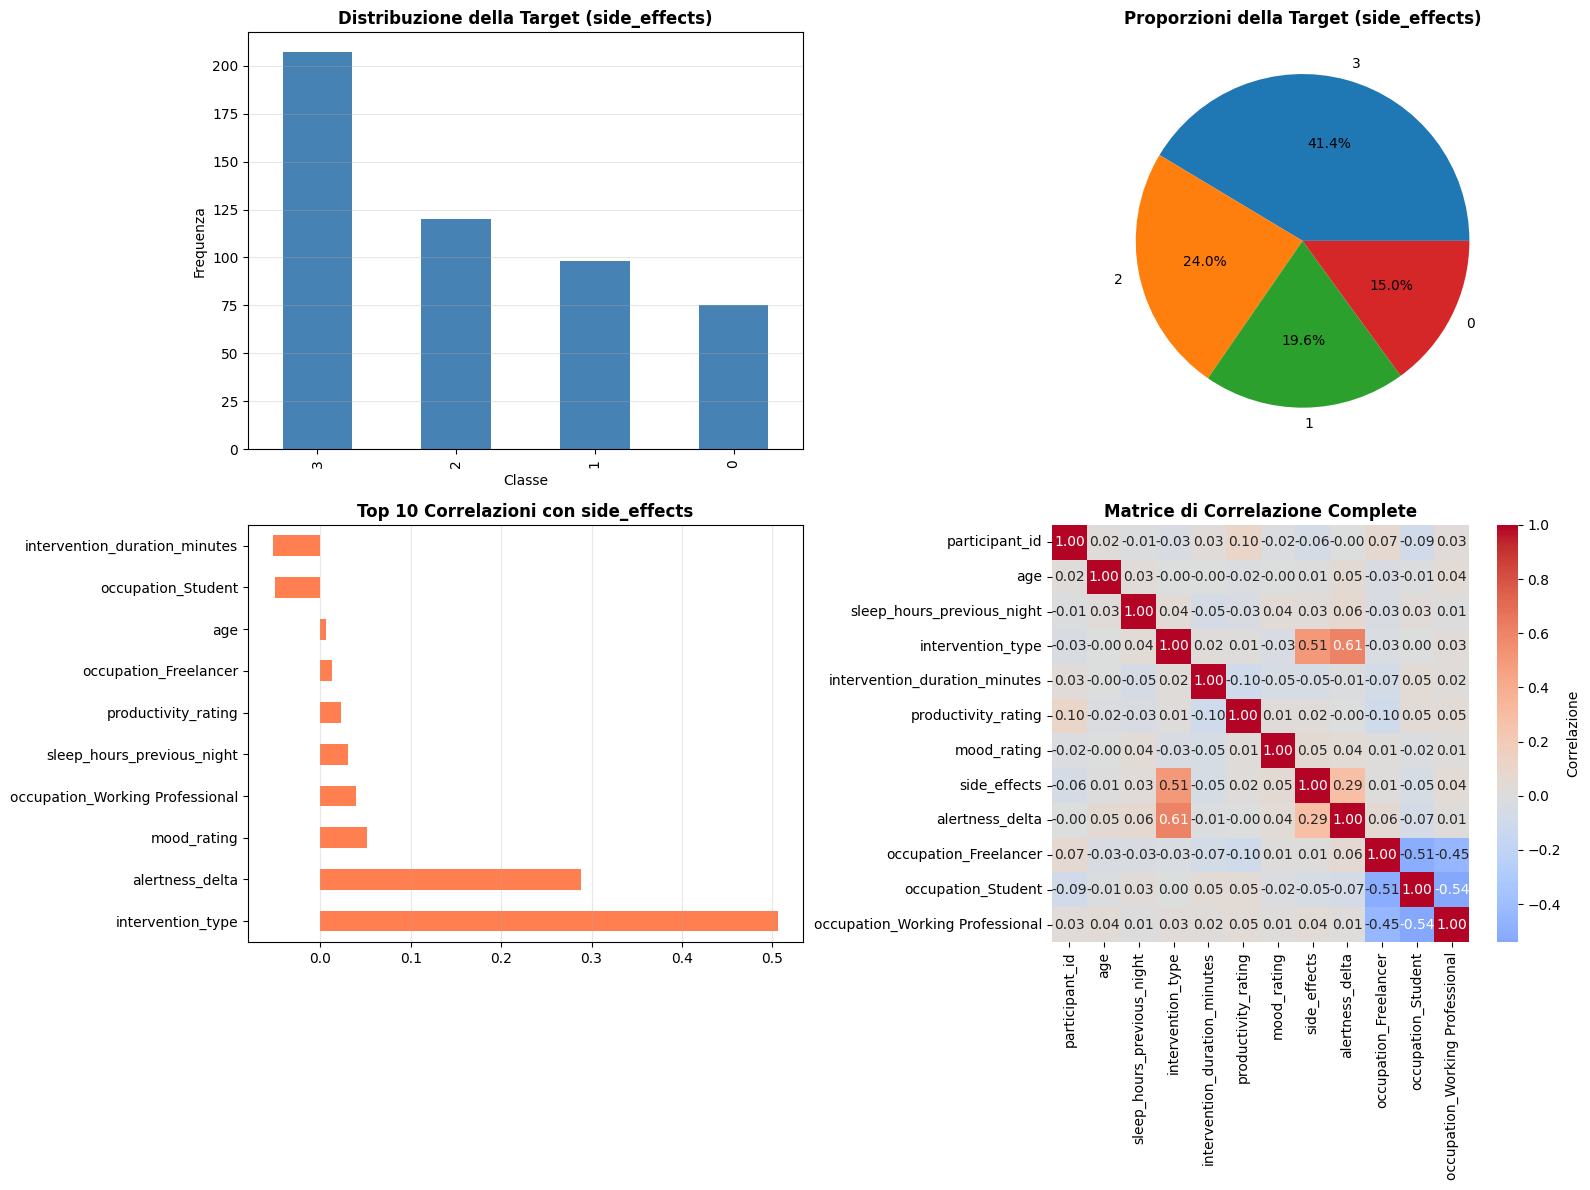

In [5]:
# Esplorazione della variabile target
print("Tipo di dato della colonna 'side_effects':")
print(df['side_effects'].dtype)

print("\nValori unici in 'side_effects':")
print(df['side_effects'].unique())

print("\nDistribuzione della target:")
print(df['side_effects'].value_counts())

# Vediamo anche la shape del dataset
print(f"\nDataset shape: {df.shape}")
print(f"\nColonne nel dataset:")
print(df.columns.tolist())

# ===== VISUALIZZAZIONI GRAFICHE =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar plot della distribuzione della target
ax1 = axes[0, 0]
df['side_effects'].value_counts().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribuzione della Target (side_effects)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Classe')
ax1.set_ylabel('Frequenza')
ax1.grid(axis='y', alpha=0.3)

# 2. Pie chart della target (percentuali)
ax2 = axes[0, 1]
df['side_effects'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Proporzioni della Target (side_effects)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

# 3. Top 10 Correlazioni con la target
ax3 = axes[1, 0]
correlation_matrix = df.corr()
target_corr = correlation_matrix['side_effects'].sort_values(ascending=False)
target_corr[1:11].plot(kind='barh', ax=ax3, color='coral')
ax3.set_title('Top 10 Correlazioni con side_effects', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Heatmap di correlazione tra tutte le features
ax4 = axes[1, 1]
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax4, cbar_kws={'label': 'Correlazione'})
ax4.set_title('Matrice di Correlazione Complete', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Preparazione dei dati per il Random Forest

In [6]:
# Separazione features (X) e target (y)
X = df.drop('side_effects', axis=1)
y = df['side_effects']

print(f"Shape di X (features): {X.shape}")
print(f"Shape di y (target): {y.shape}")

# Split in train set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nDistribuzione nel train set:\n{y_train.value_counts().sort_index()}")
print(f"\nDistribuzione nel test set:\n{y_test.value_counts().sort_index()}")

Shape di X (features): (500, 11)
Shape di y (target): (500,)

Train set size: 400
Test set size: 100

Distribuzione nel train set:
side_effects
0     60
1     78
2     96
3    166
Name: count, dtype: int64

Distribuzione nel test set:
side_effects
0    15
1    20
2    24
3    41
Name: count, dtype: int64


Creo degli istogrammi per visualizzare la distribuzione della variabile target nel Training Set e nel Testing set

[Text(0, 0, 'Anxiety (0)'),
 Text(1, 0, 'Crash (1)'),
 Text(2, 0, 'Grogginess (2)'),
 Text(3, 0, 'None (3)')]

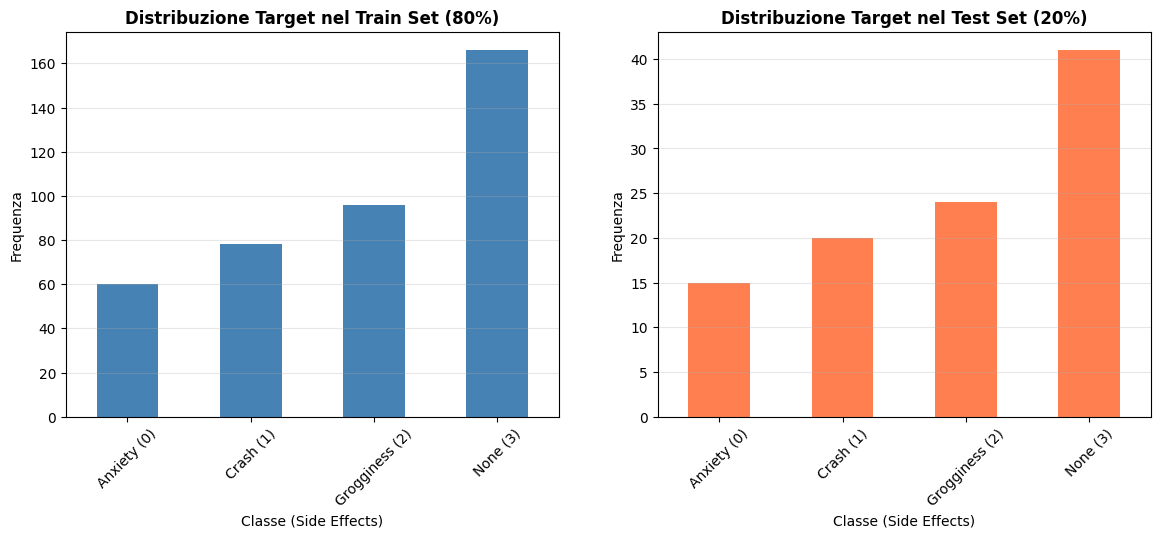

In [7]:
# Visualizzazione della distribuzione della target nei set di train e test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma Train Set
ax1 = axes[0]
y_train.value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribuzione Target nel Train Set (80%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Classe (Side Effects)')
ax1.set_ylabel('Frequenza')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(['Anxiety (0)', 'Crash (1)', 'Grogginess (2)', 'None (3)'], rotation=45)

# Istogramma Test Set
ax2 = axes[1]
y_test.value_counts().sort_index().plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Distribuzione Target nel Test Set (20%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Classe (Side Effects)')
ax2.set_ylabel('Frequenza')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(['Anxiety (0)', 'Crash (1)', 'Grogginess (2)', 'None (3)'], rotation=45)


## 4. Addestramento del Random Forest

In [8]:
# Inizializzazione e addestramento del modello
# Il numero di alberi e la profondità sono stati suggeriti da Claude sulla base del nostro database
rf_model = RandomForestClassifier(
    n_estimators=50,        # Numero di alberi nella foresta
    max_depth=5,            # Profondità massima degli alberi
    min_samples_split=10,     # Min campioni per dividere un nodo
    min_samples_leaf=5,      # Min campioni in una foglia
    random_state=42,
    n_jobs=-1,                # Usa tutti i core del processore
    class_weight="balanced"
)

# Addestramento
print("\n--- Addestramento del modello ---")
rf_model.fit(X_train, y_train)
print("Modello addestrato!")

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")


--- Addestramento del modello ---
Modello addestrato!

Accuratezza sul Train Set: 0.6350
Accuratezza sul Test Set: 0.4100


Eseguo delle analisi più dettagliate sulle feature (questa cosa è successa DOPO il fallimento critico del random forest)

Feature Importance:
                            Feature  Importance
3                 intervention_type    0.412338
7                   alertness_delta    0.180830
2        sleep_hours_previous_night    0.092331
0                    participant_id    0.081490
6                       mood_rating    0.056662
1                               age    0.054644
5               productivity_rating    0.053724
4     intervention_duration_minutes    0.030895
10  occupation_Working Professional    0.015387
9                occupation_Student    0.013665
8             occupation_Freelancer    0.008034


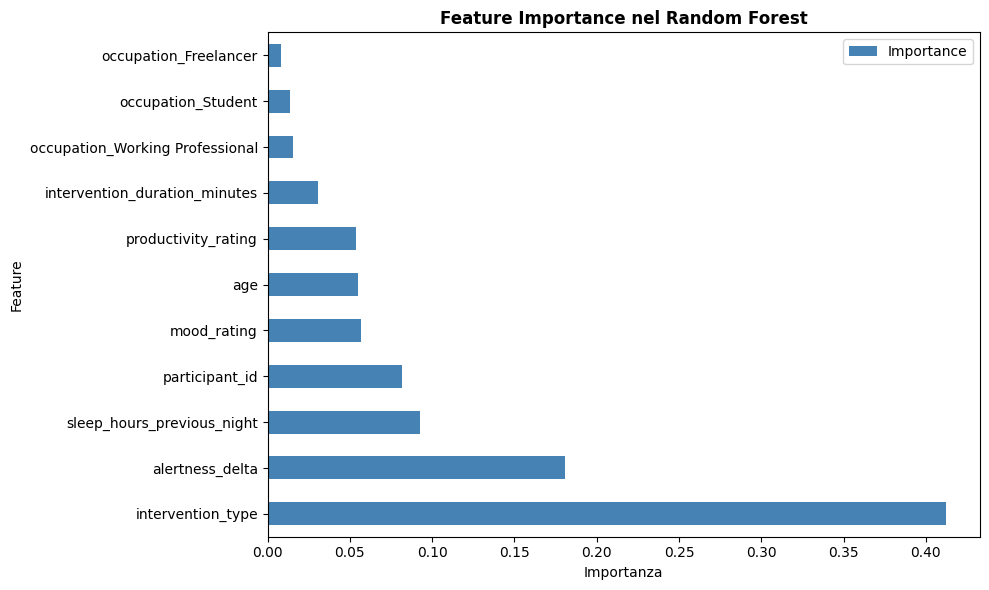

In [9]:
# 1. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Grafico
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance nel Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importanza')
plt.tight_layout()
plt.show()


participant_id è il 3° predittore più importante, ma è solo un ID univoco! Questo suggerisce che il modello sta memorizzando pattern legati a specifici partecipanti piuttosto che imparare pattern generali. Questo è un segnale di overfitting.

In [10]:
# 2. CLASSIFICATION REPORT
from sklearn.metrics import classification_report
y_pred = rf_model.predict(X_test)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Anxiety (0)', 'Crash (1)', 'Grogginess (2)', 'None (3)']))


=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

   Anxiety (0)       0.25      0.47      0.33        15
     Crash (1)       0.35      0.45      0.39        20
Grogginess (2)       0.53      0.96      0.69        24
      None (3)       0.67      0.05      0.09        41

      accuracy                           0.41       100
     macro avg       0.45      0.48      0.37       100
  weighted avg       0.51      0.41      0.33       100




=== CONFUSION MATRIX ===
[[ 7  8  0  0]
 [11  9  0  0]
 [ 0  0 23  1]
 [10  9 20  2]]


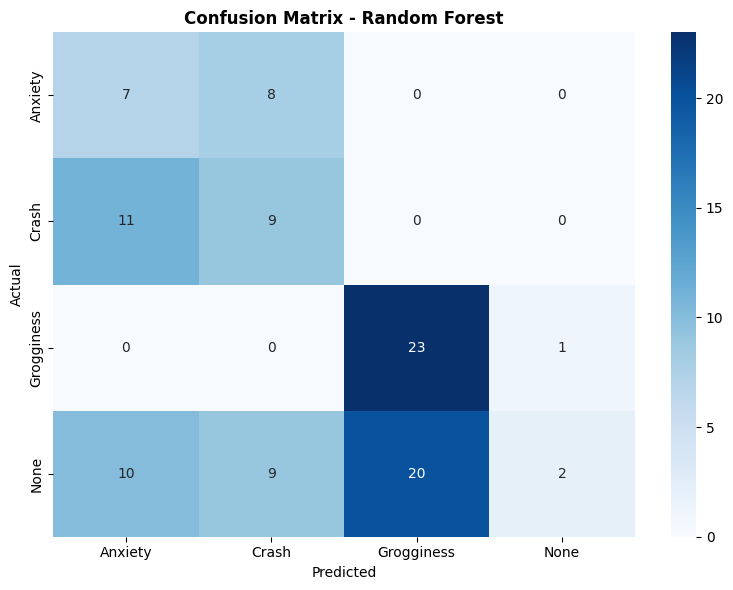

In [11]:
# 3. CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

# Heatmap della confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Anxiety', 'Crash', 'Grogginess', 'None'],
            yticklabels=['Anxiety', 'Crash', 'Grogginess', 'None'])
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 5. Data adjustment dopo il fallimento della prima foresta

Come prima cosa rimuovo Patient_ID per cercare di ridurre overfitting byas

In [12]:
# Separazione features (X) e target (y)
# Rimuoviamo sia side_effects (target) che participant_id (non è una vera feature)
X = df.drop(['side_effects', 'participant_id'], axis=1)
y = df['side_effects']

print(f"Shape di X (features): {X.shape}")
print(f"Shape di y (target): {y.shape}")
print(f"Colonne utilizzate come features:\n{X.columns.tolist()}")

# Split in train set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nDistribuzione nel train set:\n{y_train.value_counts().sort_index()}")
print(f"\nDistribuzione nel test set:\n{y_test.value_counts().sort_index()}")

Shape di X (features): (500, 10)
Shape di y (target): (500,)
Colonne utilizzate come features:
['age', 'sleep_hours_previous_night', 'intervention_type', 'intervention_duration_minutes', 'productivity_rating', 'mood_rating', 'alertness_delta', 'occupation_Freelancer', 'occupation_Student', 'occupation_Working Professional']

Train set size: 400
Test set size: 100

Distribuzione nel train set:
side_effects
0     60
1     78
2     96
3    166
Name: count, dtype: int64

Distribuzione nel test set:
side_effects
0    15
1    20
2    24
3    41
Name: count, dtype: int64


Dopo aver eseguito questi passaggi correttivi, ri-addestro il modello e vedo che succede:

In [13]:
# Inizializzazione e addestramento del modello
# Il numero di alberi e la profondità sono stati suggeriti da Claude sulla base del nostro database
rf_model = RandomForestClassifier(
    n_estimators=50,        # Numero di alberi nella foresta
    max_depth=10,            # Profondità massima degli alberi
    min_samples_split=10,     # Min campioni per dividere un nodo
    min_samples_leaf=5,      # Min campioni in una foglia
    random_state=42,
    class_weight="balanced",
    n_jobs=-1                # Usa tutti i core del processore
)

# Addestramento
print("\n--- Addestramento del modello ---")
rf_model.fit(X_train, y_train)
print("Modello addestrato!")

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")


--- Addestramento del modello ---
Modello addestrato!

Accuratezza sul Train Set: 0.7475
Accuratezza sul Test Set: 0.4900


Feature Importance:
                           Feature  Importance
2                intervention_type    0.404863
6                  alertness_delta    0.141508
1       sleep_hours_previous_night    0.119472
0                              age    0.089178
4              productivity_rating    0.077318
5                      mood_rating    0.073844
3    intervention_duration_minutes    0.048035
9  occupation_Working Professional    0.016617
8               occupation_Student    0.016203
7            occupation_Freelancer    0.012963


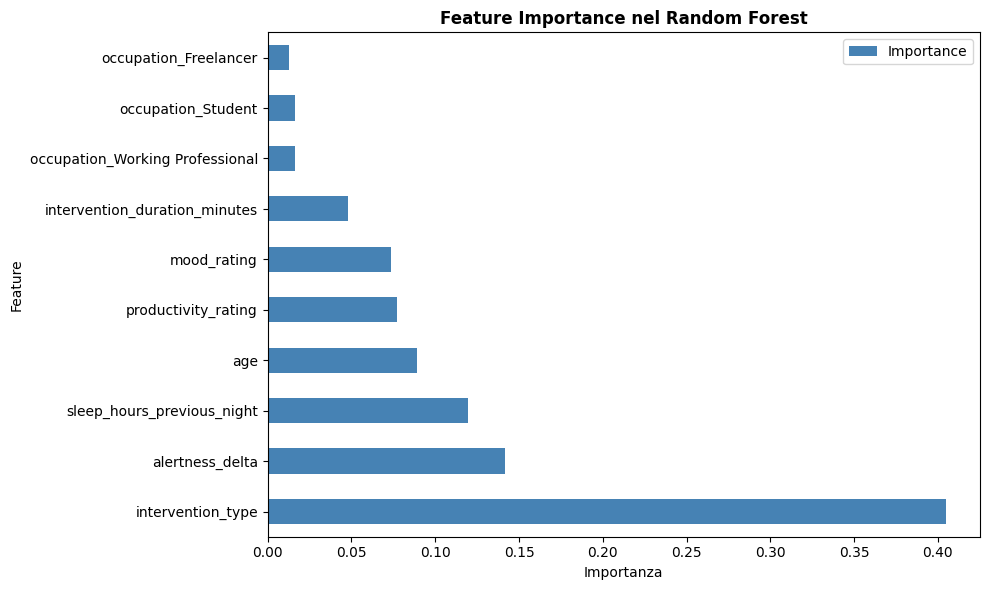

In [14]:
# 1. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Grafico
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance nel Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importanza')
plt.tight_layout()
plt.show()


## 6. Cambiamento da multiclass a binario

Controllo se il problema è lo sbilanciamento delle classi, che dovrebbe essere ovviato da weight = balanced. Per fare questo riprendo la variabile side effect, trasformo in classe negativa i side effect e in classe positiva i none (ci saranno modi più eleganti ma è per fare una prova)

In [15]:
df_new = df.copy()
#creo un dataframe nuovo così non lo sporco per dopo
df_new["side_effects"] = (df_new["side_effects"] >= 3) #se minore di 3 diventa 0 altrimenti 1
df_new.head()


,participant_id,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,side_effects,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
0,1,-0.851162,-0.579904,1,-1.292288,-0.131719,1.575447,False,0.228256,False,False,True
1,2,0.745995,-0.403802,1,1.363099,0.220470,-0.145225,True,0.426739,False,True,False
2,3,0.131704,-1.460414,0,1.363099,-1.188284,-0.145225,False,-1.161128,False,False,True
3,4,-0.359729,0.740861,0,1.363099,-0.483907,0.198910,False,-0.565678,False,True,False
4,5,-0.728304,-1.196261,1,1.363099,-0.836096,0.198910,False,0.823706,False,False,True


In [16]:
# Separazione features (X) e target (y)
# Rimuoviamo sia side_effects (target) che participant_id (non è una vera feature)
X = df_new.drop(['side_effects', 'participant_id'], axis=1)
y = df_new['side_effects']

print(f"Shape di X (features): {X.shape}")
print(f"Shape di y (target): {y.shape}")
print(f"Colonne utilizzate come features:\n{X.columns.tolist()}")

# Split in train set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nDistribuzione nel train set:\n{y_train.value_counts().sort_index()}")
print(f"\nDistribuzione nel test set:\n{y_test.value_counts().sort_index()}")

Shape di X (features): (500, 10)
Shape di y (target): (500,)
Colonne utilizzate come features:
['age', 'sleep_hours_previous_night', 'intervention_type', 'intervention_duration_minutes', 'productivity_rating', 'mood_rating', 'alertness_delta', 'occupation_Freelancer', 'occupation_Student', 'occupation_Working Professional']

Train set size: 400
Test set size: 100

Distribuzione nel train set:
side_effects
False    234
True     166
Name: count, dtype: int64

Distribuzione nel test set:
side_effects
False    59
True     41
Name: count, dtype: int64


In [17]:
# Inizializzazione e addestramento del modello
# Il numero di alberi e la profondità sono stati suggeriti da Claude sulla base del nostro database
rf_model = RandomForestClassifier(
    n_estimators=50,        # Numero di alberi nella foresta
    max_depth=5,            # Profondità massima degli alberi
    min_samples_split=10,     # Min campioni per dividere un nodo
    min_samples_leaf=5,      # Min campioni in una foglia
    random_state=42,
    n_jobs=-1                # Usa tutti i core del processore
)

# Addestramento
print("\n--- Addestramento del modello ---")
rf_model.fit(X_train, y_train)
print("Modello addestrato!")

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")


--- Addestramento del modello ---
Modello addestrato!

Accuratezza sul Train Set: 0.7600
Accuratezza sul Test Set: 0.6400


Feature Importance:
                           Feature  Importance
1       sleep_hours_previous_night    0.208636
6                  alertness_delta    0.208272
0                              age    0.144498
5                      mood_rating    0.133740
4              productivity_rating    0.082189
2                intervention_type    0.072231
3    intervention_duration_minutes    0.067286
9  occupation_Working Professional    0.031947
7            occupation_Freelancer    0.026611
8               occupation_Student    0.024590


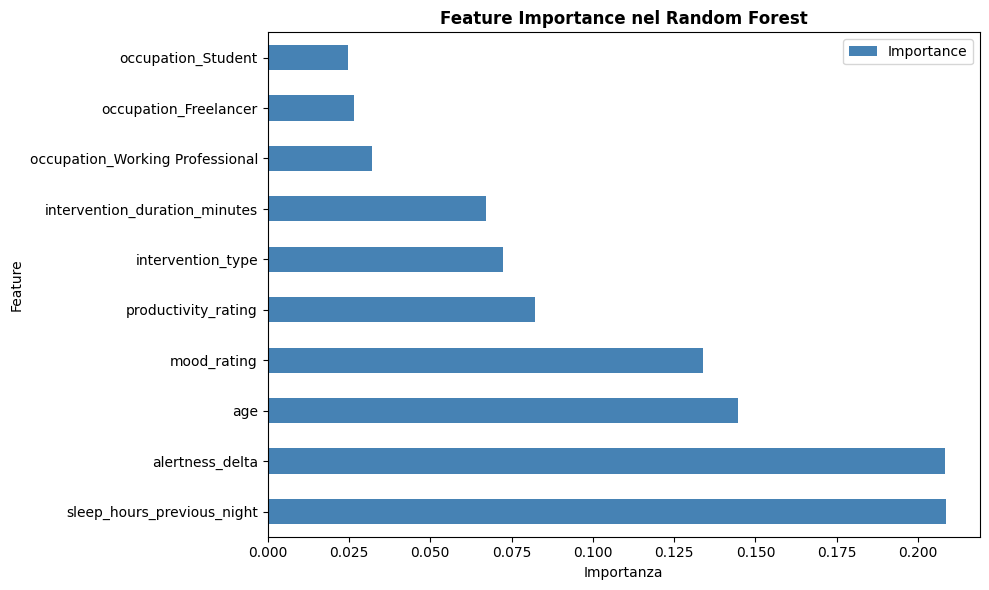

In [18]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Grafico
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance nel Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importanza')
plt.tight_layout()
plt.show()

## EXTRA: Random Forest model comparison per intervention Type


In questo blocco extra voglio provare a separare il df_encoded in due differenti df sulla base dell'intervention type, poi vedere se un modello random forest produce feature di differente importance in base ai diversi side effects
(forse ha più senso prima togliere il test, poi splittare solo il train e vedere se i due modelli hanno capacità di previsione differente sullo stesso test, ma adesso na cosa per volta qui stiamo facendo cose a caso oh)

1) Creazione dei DataFrame separati

In [ ]:

# Creiamo i due dataframe 
# (mi pare 1 fosse PNap e 0 Coffee, ma devo ricontrollare)
df_encoded_pnap = df[df['intervention_type'] == 1].copy()  # Power Nap
df_encoded_coffee = df[df['intervention_type'] == 0].copy()  # Coffee

# Visualizziamo le info
print(f"\n=== POWER NAP DATASET ===")
print(f"Shape: {df_encoded_pnap.shape}")
print(f"Distribuzione side_effects:\n{df_encoded_pnap['side_effects'].value_counts().sort_index()}")

print(f"\n=== COFFEE DATASET ===")
print(f"Shape: {df_encoded_coffee.shape}")
print(f"Distribuzione side_effects:\n{df_encoded_coffee['side_effects'].value_counts().sort_index()}")

# Verifica che i due dataset abbiano tutto
print(f"\nVerifica: {df_encoded_pnap.shape[0]} + {df_encoded_coffee.shape[0]} = {df_encoded_pnap.shape[0] + df_encoded_coffee.shape[0]} (dovrebbe essere 500)")


=== POWER NAP DATASET ===
Shape: (239, 12)
Distribuzione side_effects:
side_effects
2    120
3    119
Name: count, dtype: int64

=== COFFEE DATASET ===
Shape: (261, 12)
Distribuzione side_effects:
side_effects
0    75
1    98
3    88
Name: count, dtype: int64

Verifica: 239 + 261 = 500 (dovrebbe essere 500)


Divido i due nuovi df in "test e train" e studio le distribuzioni delle variabili target

In [20]:
# ===== SPLIT DATASET POWER NAP =====
print("="*60)
print("POWER NAP DATASET - TRAIN/TEST SPLIT")
print("="*60)

# Features e target per Power Nap
X_pnap = df_encoded_pnap.drop(['side_effects', 'participant_id'], axis=1)
y_pnap = df_encoded_pnap['side_effects']

# Split
X_train_pnap, X_test_pnap, y_train_pnap, y_test_pnap = train_test_split(
    X_pnap, y_pnap,
    test_size=0.2,
    random_state=42,
    stratify=y_pnap
)

print(f"Train set size: {X_train_pnap.shape[0]}")
print(f"Test set size: {X_test_pnap.shape[0]}")
print(f"\nDistribuzione nel train set:\n{y_train_pnap.value_counts().sort_index()}")
print(f"\nDistribuzione nel test set:\n{y_test_pnap.value_counts().sort_index()}")

# ===== SPLIT DATASET COFFEE =====
print("\n" + "="*60)
print("COFFEE DATASET - TRAIN/TEST SPLIT")
print("="*60)

# Features e target per Coffee
X_coffee = df_encoded_coffee.drop(['side_effects', 'participant_id'], axis=1)
y_coffee = df_encoded_coffee['side_effects']

# Split
X_train_coffee, X_test_coffee, y_train_coffee, y_test_coffee = train_test_split(
    X_coffee, y_coffee,
    test_size=0.2,
    random_state=42,
    stratify=y_coffee
)

print(f"Train set size: {X_train_coffee.shape[0]}")
print(f"Test set size: {X_test_coffee.shape[0]}")
print(f"\nDistribuzione nel train set:\n{y_train_coffee.value_counts().sort_index()}")
print(f"\nDistribuzione nel test set:\n{y_test_coffee.value_counts().sort_index()}")

POWER NAP DATASET - TRAIN/TEST SPLIT
Train set size: 191
Test set size: 48

Distribuzione nel train set:
side_effects
2    96
3    95
Name: count, dtype: int64

Distribuzione nel test set:
side_effects
2    24
3    24
Name: count, dtype: int64

COFFEE DATASET - TRAIN/TEST SPLIT
Train set size: 208
Test set size: 53

Distribuzione nel train set:
side_effects
0    60
1    78
3    70
Name: count, dtype: int64

Distribuzione nel test set:
side_effects
0    15
1    20
3    18
Name: count, dtype: int64


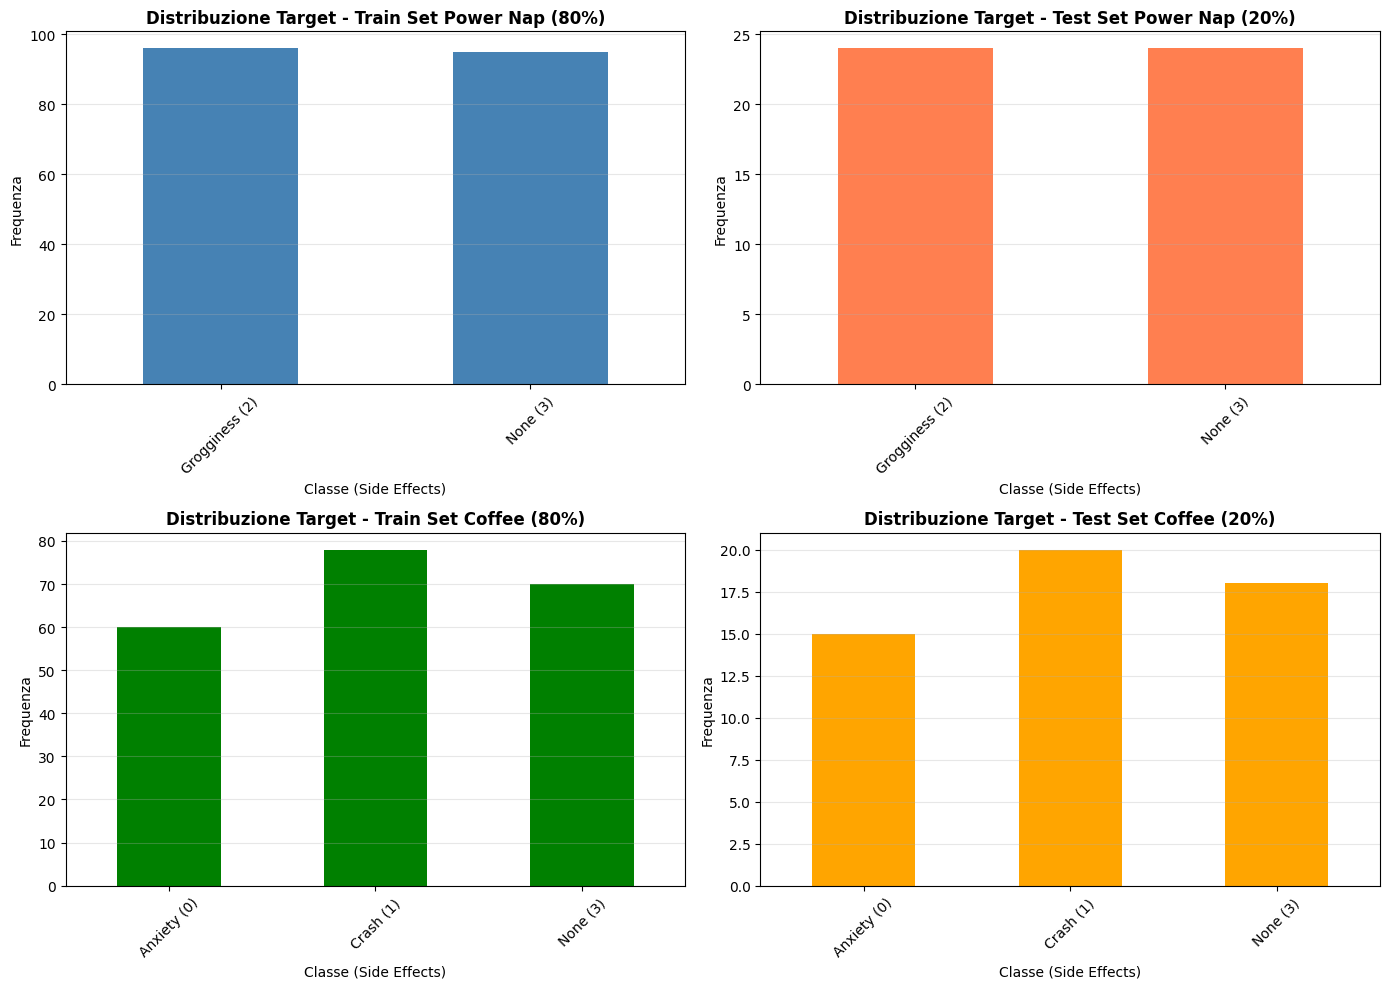

In [22]:
# Mapping dei label
label_map = {0: 'Anxiety (0)', 1: 'Crash (1)', 2: 'Grogginess (2)', 3: 'None (3)'}

# Visualizzazione della distribuzione della target nei set di train e test per entrambi gli interventi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AltoSX: Train Set POWER NAP
ax1 = axes[0, 0]
counts_pnap_train = y_train_pnap.value_counts().sort_index()
counts_pnap_train.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_xticklabels([label_map[i] for i in counts_pnap_train.index], rotation=45)
ax1.set_title('Distribuzione Target - Train Set Power Nap (80%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Classe (Side Effects)')
ax1.set_ylabel('Frequenza')
ax1.grid(axis='y', alpha=0.3)

# AltoDX: Test Set POWER NAP
ax2 = axes[0, 1]
counts_pnap_test = y_test_pnap.value_counts().sort_index()
counts_pnap_test.plot(kind='bar', ax=ax2, color='coral')
ax2.set_xticklabels([label_map[i] for i in counts_pnap_test.index], rotation=45)
ax2.set_title('Distribuzione Target - Test Set Power Nap (20%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Classe (Side Effects)')
ax2.set_ylabel('Frequenza')
ax2.grid(axis='y', alpha=0.3)

# BassoSX: Train Set COFFEE
ax3 = axes[1, 0]
counts_coffee_train = y_train_coffee.value_counts().sort_index()
counts_coffee_train.plot(kind='bar', ax=ax3, color='green')
ax3.set_xticklabels([label_map[i] for i in counts_coffee_train.index], rotation=45)
ax3.set_title('Distribuzione Target - Train Set Coffee (80%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Classe (Side Effects)')
ax3.set_ylabel('Frequenza')
ax3.grid(axis='y', alpha=0.3)

# BassoDX: Test Set COFFEE
ax4 = axes[1, 1]
counts_coffee_test = y_test_coffee.value_counts().sort_index()
counts_coffee_test.plot(kind='bar', ax=ax4, color='orange')
ax4.set_xticklabels([label_map[i] for i in counts_coffee_test.index], rotation=45)
ax4.set_title('Distribuzione Target - Test Set Coffee (20%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Classe (Side Effects)')
ax4.set_ylabel('Frequenza')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# ===== TRAIN POWER NAP MODEL =====
print("="*60)
print("TRAINING POWER NAP MODEL")
print("="*60)

rf_model_pnap = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_pnap.fit(X_train_pnap, y_train_pnap)
print("✓ Power Nap model trained!")

# ===== PREDICTIONS & EVALUATION FOR POWER NAP =====
print("\n" + "="*60)
print("POWER NAP MODEL - PREDICTIONS & EVALUATION")
print("="*60)

y_pred_pnap = rf_model_pnap.predict(X_test_pnap)
train_acc_pnap = rf_model_pnap.score(X_train_pnap, y_train_pnap)
test_acc_pnap = rf_model_pnap.score(X_test_pnap, y_test_pnap)

print(f"\nTrain Accuracy: {train_acc_pnap:.4f}")
print(f"Test Accuracy:  {test_acc_pnap:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_pnap, y_pred_pnap)}")

TRAINING POWER NAP MODEL
✓ Power Nap model trained!

POWER NAP MODEL - PREDICTIONS & EVALUATION

Train Accuracy: 0.8639
Test Accuracy:  0.6250

Classification Report:
              precision    recall  f1-score   support

           2       0.62      0.67      0.64        24
           3       0.64      0.58      0.61        24

    accuracy                           0.62        48
   macro avg       0.63      0.62      0.62        48
weighted avg       0.63      0.62      0.62        48



In [29]:
# ===== TRAIN COFFEE MODEL =====
print("\n" + "="*60)
print("TRAINING COFFEE MODEL")
print("="*60)

rf_model_coffee = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_coffee.fit(X_train_coffee, y_train_coffee)
print("✓ Coffee model trained!")

# ===== PREDICTIONS & EVALUATION FOR COFFEE =====
print("\n" + "="*60)
print("COFFEE MODEL - PREDICTIONS & EVALUATION")
print("="*60)

y_pred_coffee = rf_model_coffee.predict(X_test_coffee)
train_acc_coffee = rf_model_coffee.score(X_train_coffee, y_train_coffee)
test_acc_coffee = rf_model_coffee.score(X_test_coffee, y_test_coffee)

print(f"\nTrain Accuracy: {train_acc_coffee:.4f}")
print(f"Test Accuracy:  {test_acc_coffee:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_coffee, y_pred_coffee)}")


TRAINING COFFEE MODEL
✓ Coffee model trained!

COFFEE MODEL - PREDICTIONS & EVALUATION

Train Accuracy: 0.8125
Test Accuracy:  0.3396

Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.33      0.30        15
           1       0.23      0.15      0.18        20
           3       0.45      0.56      0.50        18

    accuracy                           0.34        53
   macro avg       0.32      0.35      0.33        53
weighted avg       0.32      0.34      0.32        53




MODEL COMPARISON SUMMARY
  Intervention  Train Accuracy  Test Accuracy  Overfitting Gap
0    Power Nap        0.863874       0.625000         0.238874
1       Coffee        0.812500       0.339623         0.472877


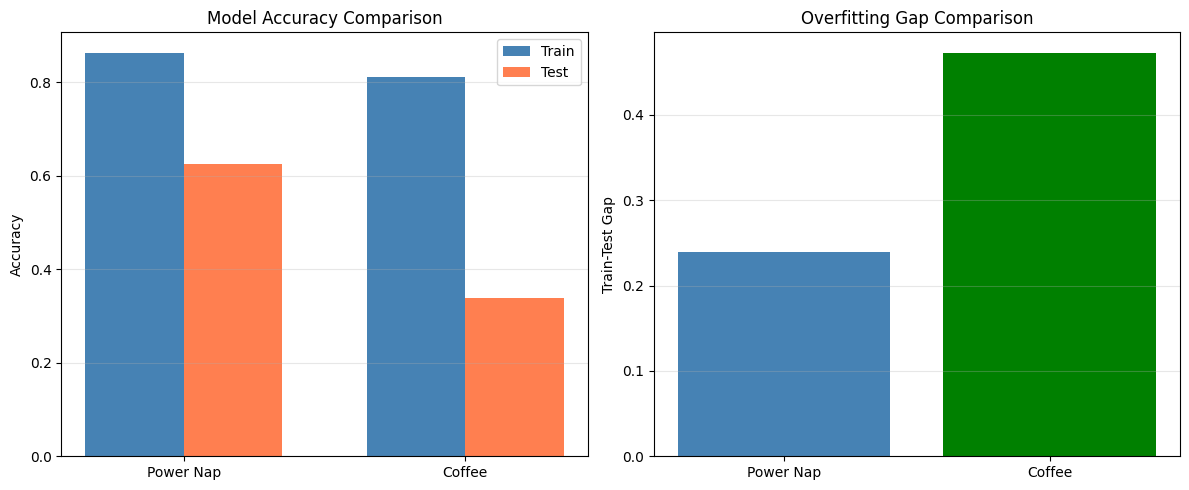

In [30]:
# ===== MODEL COMPARISON =====
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Intervention': ['Power Nap', 'Coffee'],
    'Train Accuracy': [train_acc_pnap, train_acc_coffee],
    'Test Accuracy': [test_acc_pnap, test_acc_coffee],
    'Overfitting Gap': [train_acc_pnap - test_acc_pnap, train_acc_coffee - test_acc_coffee]
})

print(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1 = axes[0]
x = np.arange(2)
width = 0.35
ax1.bar(x - width/2, [train_acc_pnap, train_acc_coffee], width, label='Train', color='steelblue')
ax1.bar(x + width/2, [test_acc_pnap, test_acc_coffee], width, label='Test', color='coral')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(['Power Nap', 'Coffee'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Overfitting gap
ax2 = axes[1]
gaps = [train_acc_pnap - test_acc_pnap, train_acc_coffee - test_acc_coffee]
ax2.bar(['Power Nap', 'Coffee'], gaps, color=['steelblue', 'green'])
ax2.set_ylabel('Train-Test Gap')
ax2.set_title('Overfitting Gap Comparison')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE COMPARISON

Power Nap - Top 5 Features:
                      Feature  Importance
6             alertness_delta    0.224802
1  sleep_hours_previous_night    0.190396
0                         age    0.169486
5                 mood_rating    0.116670
4         productivity_rating    0.106356

Coffee - Top 5 Features:
                      Feature  Importance
1  sleep_hours_previous_night    0.229192
5                 mood_rating    0.171420
4         productivity_rating    0.149620
0                         age    0.148652
6             alertness_delta    0.136245


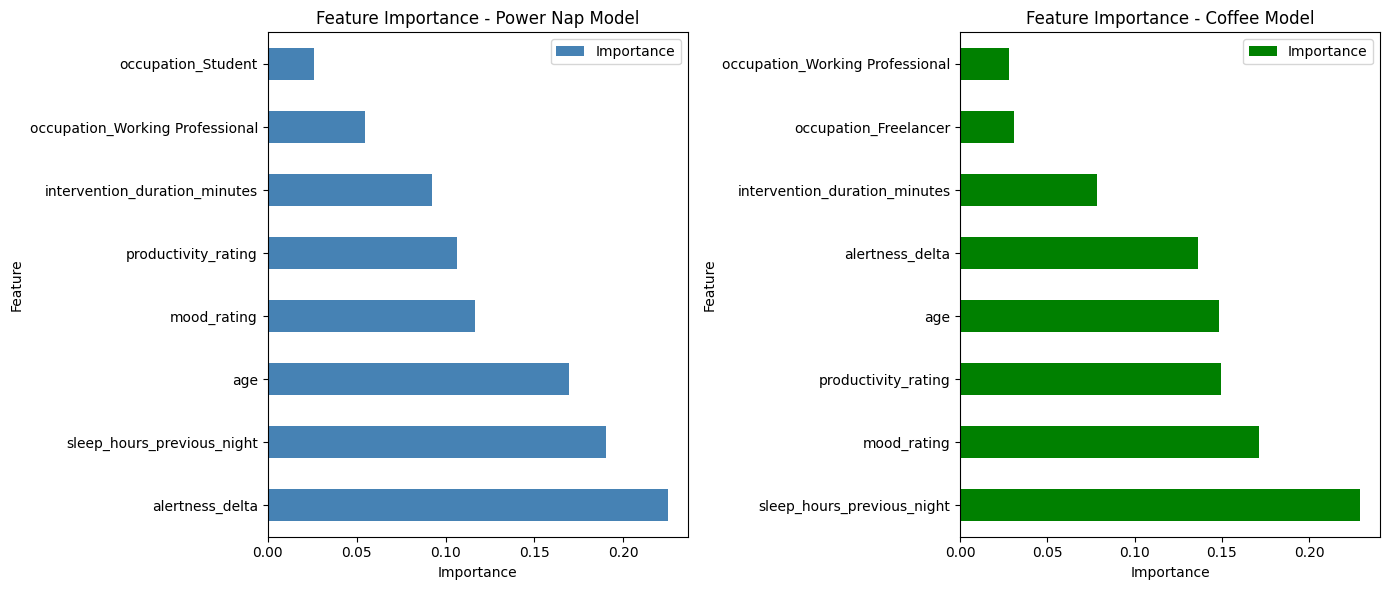

In [27]:
# ===== FEATURE IMPORTANCE COMPARISON =====
print("\n" + "="*60)
print("FEATURE IMPORTANCE COMPARISON")
print("="*60)

# Power Nap
feature_imp_pnap = pd.DataFrame({
    'Feature': X_train_pnap.columns,
    'Importance': rf_model_pnap.feature_importances_
}).sort_values('Importance', ascending=False)

# Coffee
feature_imp_coffee = pd.DataFrame({
    'Feature': X_train_coffee.columns,
    'Importance': rf_model_coffee.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nPower Nap - Top 5 Features:")
print(feature_imp_pnap.head())

print("\nCoffee - Top 5 Features:")
print(feature_imp_coffee.head())

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Power Nap
feature_imp_pnap.head(8).plot(x='Feature', y='Importance', kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance - Power Nap Model')
axes[0].set_xlabel('Importance')

# Coffee
feature_imp_coffee.head(8).plot(x='Feature', y='Importance', kind='barh', ax=axes[1], color='green')
axes[1].set_title('Feature Importance - Coffee Model')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()